# Meteorological Indicators, Exposure, and EF Rating in U.S. Tornadoes, 2010-2025

## 1. Study Overview

Use tornado records, radar, warnings, and land cover to classify EF0-EF5 ratings for 2010-2025.
First compare learning rates, L2, and dropout under the same training conditions. Then remove
feature groups to see which information helps the selected model.

EF is a post-event damage rating. Final-track features share information with that rating,
so this is a retrospective analysis.

## 2. Setup

Use the project `.venv`, or uncomment the install line below in a fresh environment.
Fix seeds and training settings so the experiments can be compared. Results are displayed
and saved under `assets/` and `data/results/`.

In [1]:
# %pip install geopandas kagglehub matplotlib numpy pandas pyarrow scikit-learn tensorflow

import json
import os
import platform
import random
import textwrap
from dataclasses import dataclass, replace
from pathlib import Path
from typing import TYPE_CHECKING, Literal

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import geopandas as gpd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# tf.keras loads lazily; the public Keras package provides the same types for static checks.
if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

# Let the notebook share GPU memory with other processes, including a VS Code kernel.
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

runtime = {
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "keras": keras.__version__,
    "devices": [device.name for device in tf.config.list_physical_devices()],
}
print(json.dumps(runtime, indent=2))

# Python, NumPy, and TensorFlow seeds; reset again before every model.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

BASE_DIR = Path.cwd()
SOURCE_DIR = BASE_DIR / "data/source/v8"
RESULTS_DIR = BASE_DIR / "data/results"
FIGURE_DIR = BASE_DIR / "assets/figures"
TABLE_DIR = BASE_DIR / "assets/tables"
for directory in (SOURCE_DIR, RESULTS_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [f"EF{i}" for i in range(6)]
N_CLASSES = len(CLASS_NAMES)
# Forward-in-time split: train on earlier tornadoes, validate and test on later ones.
YEARS = {"train": (2010, 2019), "validation": (2020, 2022), "test": (2023, 2025)}
SPLIT_ORDER = list(YEARS)
# Shared training budget for every experiment.
EPOCHS, BATCH_SIZE = 50, 64

EF_COLORS = dict(
    zip(
        [*CLASS_NAMES, "Unknown"],
        ["#F2C94C", "#F29E38", "#ED6A32", "#D93632", "#AD203E", "#650026", "#999999"],
        strict=True,
    )
)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    }
)

I0000 00:00:1789619699.508415 1627890 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789619700.247693 1627890 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


{
  "python": "3.12.12",
  "tensorflow": "2.21.0",
  "keras": "3.15.1",
  "devices": [
    "/physical_device:CPU:0"
  ]
}


In [2]:
def saved(path: Path) -> None:
    print(f"Saved {path.relative_to(BASE_DIR).as_posix()}")


def show_figure(fig: plt.Figure, name: str, caption: str) -> None:
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    saved(path)


def save_table(
    frame: pd.DataFrame,
    name: str,
    title: str,
    *,
    caption: str,
    formats: dict[str, str] | None = None,
    note: str | None = None,
    emphasize: tuple[str, Literal["max", "min"]] | None = None,
    sort: bool = False,
    width: float = 9,
) -> None:
    # Save the numeric CSV plus a styled image; emphasize bolds the best cell of one column.
    best_row, best_column = None, None
    if emphasize is not None:
        best_column, direction = emphasize
        if sort:
            frame = frame.sort_values(best_column, ascending=direction == "min", ignore_index=True)
        ranked = frame[best_column]
        best_row = int(ranked.idxmax() if direction == "max" else ranked.idxmin())
    frame.to_csv(RESULTS_DIR / f"{name}.csv", index=False)
    shown = frame.copy()
    for column, pattern in (formats or {}).items():
        shown[column] = shown[column].map(
            lambda value, pattern=pattern: "-" if pd.isna(value) else format(value, pattern)
        )
    shown = shown.fillna("-").astype(str)
    note_lines = textwrap.wrap(note, width=110) if note else []
    height = 0.34 * (len(frame) + 1.5) + 0.65 + 0.18 * len(note_lines)
    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis("off")
    fig.text(0.03, 1 - 0.22 / height, title, fontsize=12, weight="bold", va="top")
    headers = [textwrap.fill(str(c), width=22) for c in frame.columns]
    column_widths = np.array(
        [
            max(max(map(len, header.splitlines())), shown[column].str.len().max()) + 3
            for column, header in zip(frame.columns, headers, strict=True)
        ],
        dtype=float,
    )
    table = ax.table(
        cellText=shown.values.tolist(),
        colLabels=headers,
        colWidths=column_widths / column_widths.sum(),
        cellLoc="right",
        colLoc="left",
        bbox=Bbox.from_bounds(0, 0, 1, 1),
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#D6DEE5")
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor("#E7EEF4")
            cell.set_text_props(weight="bold", color="#172B3A")
            cell.set_height(cell.get_height() * 1.5)
        else:
            cell.set_facecolor("#F6F8FA" if row % 2 == 0 else "white")
        if col == 0:
            cell.set_text_props(ha="left")
        if best_row is not None and row == best_row + 1 and frame.columns[col] == best_column:
            cell.set_facecolor("#DCEFD9")
            cell.set_text_props(weight="bold")
    if note_lines:
        fig.text(0.03, 0.03, "\n".join(note_lines), fontsize=9, color="#46535F")
    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=1 - 0.55 / height,
        bottom=(0.16 + 0.22 * len(note_lines)) / height,
    )
    path = TABLE_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    saved(path)
    saved(RESULTS_DIR / f"{name}.csv")

## 3. Data

[US Tornado Data, 2010-2025](https://www.kaggle.com/datasets/jakevanslyke/us-tornado-data-2010-2025/versions/8)
contains 20,164 records. Load the pinned retrospective table and its 32 allowed predictors;
keep identifiers, outcomes such as injuries, and quality fields out of the inputs.

Check class balance and geographic coverage before modeling. Exclude unknown ratings from
training; keep incomplete predictor rows and encode their missingness.

### Load

In [3]:
DATASET = "jakevanslyke/us-tornado-data-2010-2025/versions/8"
for relative in (
    "ml/events_retrospective.parquet",
    "ml/feature_dictionary.json",
    "analysis/county_boundaries.parquet",
):
    if not (SOURCE_DIR / relative).is_file():
        kagglehub.dataset_download(DATASET, path=relative, output_dir=str(SOURCE_DIR))

spec = json.loads((SOURCE_DIR / "ml/feature_dictionary.json").read_text())
ID, TARGET = spec["id"], spec["target"]
PREDICTORS = spec["retrospective_predictor_columns"]
records = pd.read_parquet(SOURCE_DIR / "ml/events_retrospective.parquet").set_index(ID)
assert records.index.is_unique
known = records[TARGET].notna()
display(
    Markdown(
        f"**{len(records):,} tornado records:** {known.sum():,} with a known EF rating and "
        f"{(~known).sum():,} unknown. {len(PREDICTORS)} allowed predictors."
    )
)

**20,164 tornado records:** 18,639 with a known EF rating and 1,525 unknown. 32 allowed predictors.

### Class balance

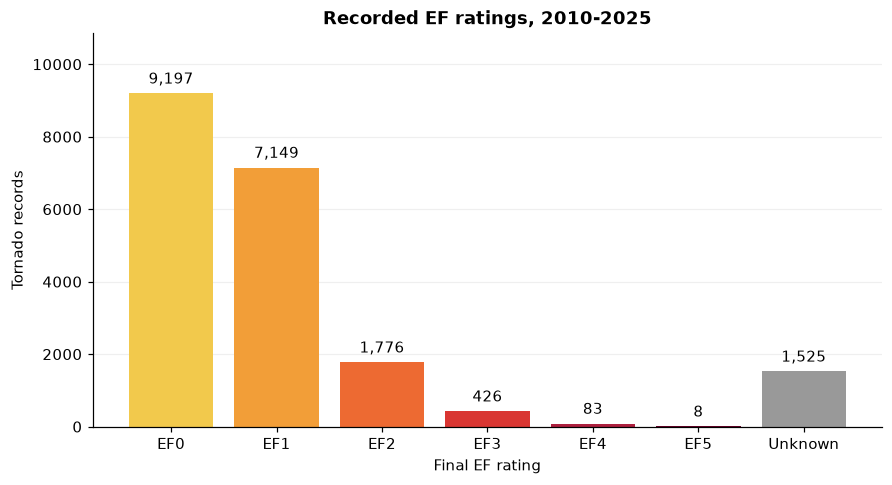

**Figure 1.** Distribution of recorded EF ratings, 2010-2025. Unknown ratings are excluded from modeling; EF4 and EF5 together hold under 100 events.

Saved assets/figures/fig_01_class_distribution.png


In [4]:
rating_labels = records[TARGET].map({i: f"EF{i}" for i in range(6)}).fillna("Unknown")
class_counts = rating_labels.value_counts().reindex(EF_COLORS, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.3), layout="constrained")
bars = ax.bar(class_counts.index, class_counts, color=[EF_COLORS[c] for c in class_counts.index])
ax.bar_label(bars, labels=[f"{n:,}" for n in class_counts], padding=4, fontsize=10)
ax.set(title="Recorded EF ratings, 2010-2025", ylabel="Tornado records", xlabel="Final EF rating")
ax.set_ylim(0, class_counts.max() * 1.18)
ax.grid(axis="y", alpha=0.2)
show_figure(
    fig,
    "fig_01_class_distribution",
    "**Figure 1.** Distribution of recorded EF ratings, 2010-2025. Unknown ratings are excluded "
    "from modeling; EF4 and EF5 together hold under 100 events.",
)

### Geographic coverage

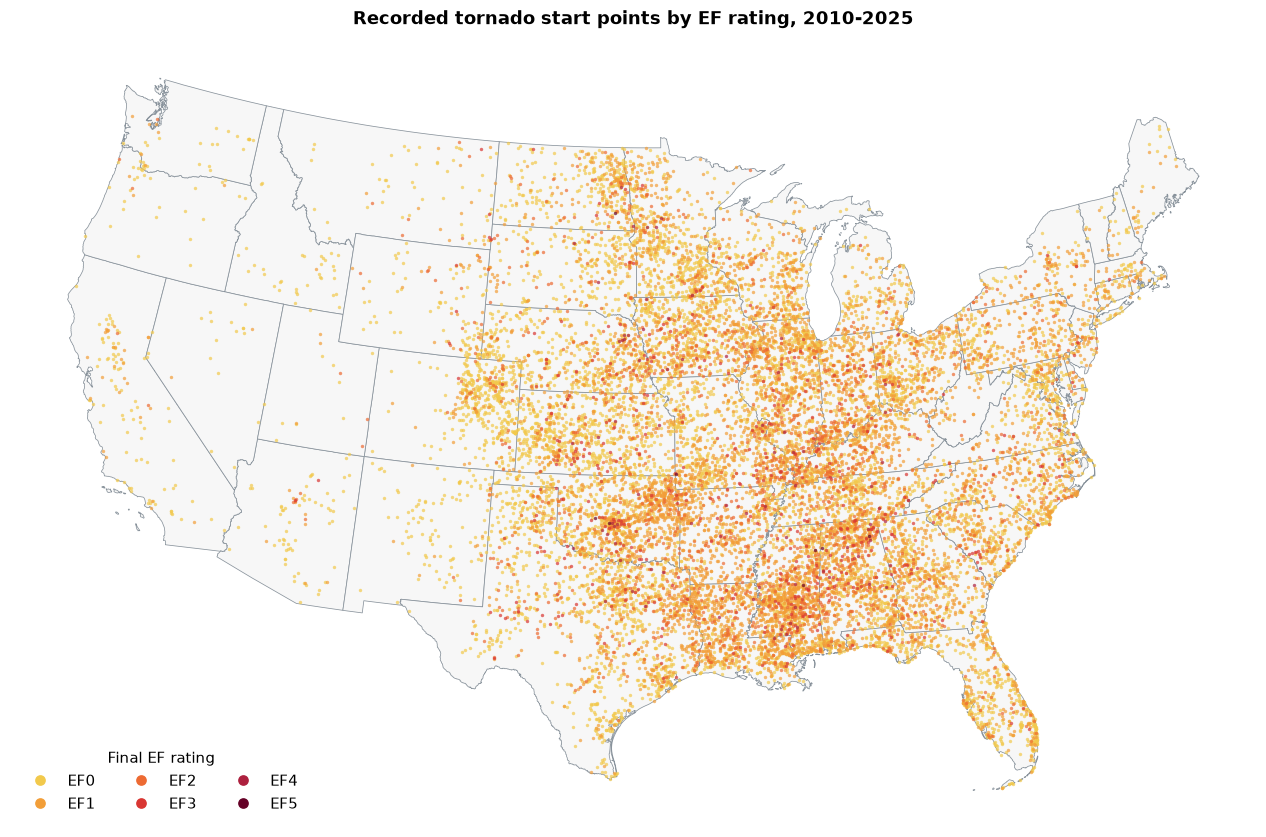

**Figure 2.** Contiguous-U.S. start points of rated tornadoes colored by EF rating. Stronger ratings are drawn last, so overlap can hide weaker points.

Saved assets/figures/fig_02_geographic_distribution.png


In [5]:
# Contiguous U.S. only for the map; the modeling cohort keeps every region.
states = gpd.read_parquet(SOURCE_DIR / "analysis/county_boundaries.parquet").dissolve("state_fips")
states = states.loc[~states.index.isin(["02", "15", "60", "66", "69", "72", "78"])].to_crs(
    "EPSG:5070"
)
rated = records.loc[
    known & records.start_longitude.between(-125, -66) & records.start_latitude.between(24, 50)
]
points = gpd.GeoDataFrame(
    rated[[TARGET]],
    geometry=gpd.points_from_xy(rated.start_longitude, rated.start_latitude),
    crs="EPSG:4326",
).to_crs(states.crs)

fig, ax = plt.subplots(figsize=(12, 7.5), layout="constrained")
states.plot(ax=ax, color="#F7F7F7", edgecolor="#89939C", linewidth=0.5)
for rating, label in enumerate(CLASS_NAMES):
    selected = points.loc[points[TARGET].eq(rating)]
    ax.scatter(
        selected.geometry.x,
        selected.geometry.y,
        s=5,
        alpha=0.7,
        color=EF_COLORS[label],
        linewidths=0,
        zorder=3 + rating,
    )
ax.set_axis_off()
ax.set_title("Recorded tornado start points by EF rating, 2010-2025", pad=12)
ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="", markersize=6, color=EF_COLORS[c], label=c)
        for c in CLASS_NAMES
    ],
    loc="lower left",
    frameon=False,
    ncol=3,
    title="Final EF rating",
)
show_figure(
    fig,
    "fig_02_geographic_distribution",
    "**Figure 2.** Contiguous-U.S. start points of rated tornadoes colored by EF rating. Stronger "
    "ratings are drawn last, so overlap can hide weaker points.",
)

## 4. Preparation

Train on 2010-2019, validate on 2020-2022, and test on 2023-2025 to assess transfer to later
years. Check that linked events stay in the same split.

Encode month and hour cyclically, log-transform skewed counts and dimensions, and impute
missing values with a median plus a missingness indicator. Fit imputation, scaling, and the
choice of log transforms on training data only.

### Split

**Split audit:** 0 linkage groups cross partitions.

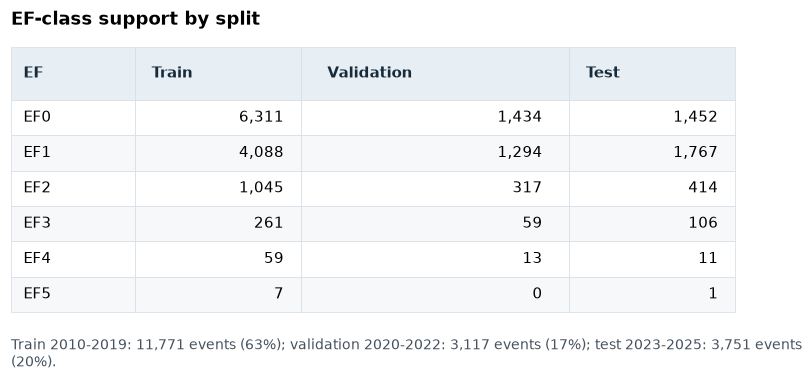

**Table 1.** Forward-in-time split. The validation years contain no EF5 event and the test years contain one, so EF5 metrics are never dependable.

Saved assets/tables/table_01_class_support.png
Saved data/results/table_01_class_support.csv


In [6]:
eligible = records.loc[known]
cohorts = {split: eligible.loc[eligible.year.between(*span)] for split, span in YEARS.items()}
assert sum(map(len, cohorts.values())) == len(eligible)
# Shared source/radar/warning linkage groups must not straddle year partitions.
GROUP = spec["group"]
assert eligible[GROUP].notna().all()
split_audit = pd.concat([frame[[GROUP]].assign(split=split) for split, frame in cohorts.items()])
cross_split_groups = int((split_audit.groupby(GROUP)["split"].nunique() > 1).sum())
assert cross_split_groups == 0, "Linked events cross split boundaries; review the split."
display(Markdown(f"**Split audit:** {cross_split_groups} linkage groups cross partitions."))

y = {split: frame[TARGET].to_numpy(dtype="int64") for split, frame in cohorts.items()}

support_table = pd.DataFrame(
    {
        "EF": CLASS_NAMES,
        **{split.title(): np.bincount(y[split], minlength=N_CLASSES) for split in SPLIT_ORDER},
    }
)
split_note = "; ".join(
    f"{split} {span[0]}-{span[1]}: {len(cohorts[split]):,} events "
    f"({100 * len(cohorts[split]) / len(eligible):.0f}%)"
    for split, span in YEARS.items()
)
save_table(
    support_table,
    "table_01_class_support",
    "EF-class support by split",
    caption="**Table 1.** Forward-in-time split. The validation years contain no EF5 event and "
    "the test years contain one, so EF5 metrics are never dependable.",
    formats={split.title(): ",d" for split in SPLIT_ORDER},
    width=7,
    note=split_note.capitalize() + ".",
)

### Features

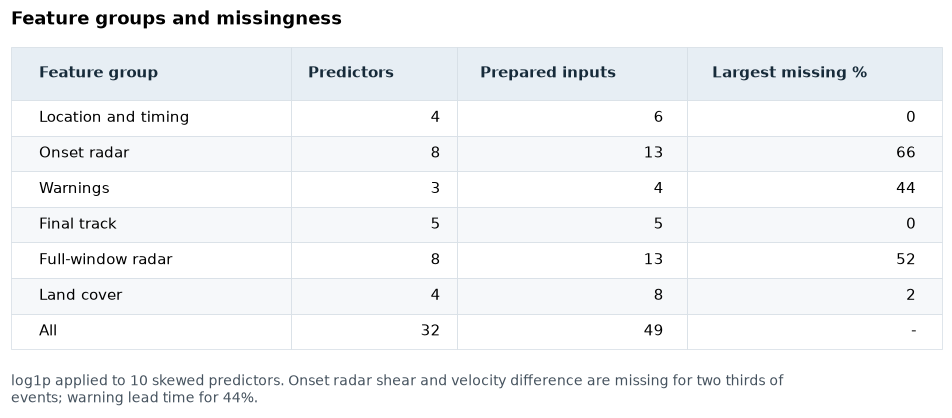

**Table 2.** Predictor and prepared-input counts per feature group, and the largest missing share within each group across all records. Prepared inputs add cyclic time pairs and missingness indicators.

Saved assets/tables/table_02_feature_groups.png
Saved data/results/table_02_feature_groups.csv


In [7]:
feature_groups = {
    "Location and timing": ["start_longitude", "start_latitude", "month", "hour_utc"],
    "Onset radar": [c for c in PREDICTORS if c.startswith("radar_")],
    "Warnings": [c for c in PREDICTORS if c.startswith("warning_")],
    "Final track": [
        "post_end_longitude",
        "post_end_latitude",
        "post_path_length_miles",
        "post_path_width_yards",
        "post_duration_minutes",
    ],
    "Full-window radar": [c for c in PREDICTORS if c.startswith("post_radar_")],
    "Land cover": [
        c for c in PREDICTORS if c.startswith("post_land_") or c == "post_impervious_mean_percent"
    ],
}
assert sorted(c for cols in feature_groups.values() for c in cols) == sorted(PREDICTORS)


def encode_predictors(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # Fixed transforms only; nothing here is estimated from data.
    encoded = frame[columns].copy()
    # The release stores hour_utc as a datetime; the integer hour comes from onset_utc.
    encoded["hour_utc"] = frame["onset_utc"].dt.hour.astype(float)
    for column, period, offset in [("month", 12, 1), ("hour_utc", 24, 0)]:
        angle = 2 * np.pi * (encoded.pop(column).astype(float) - offset) / period
        encoded[f"{column}_sin"] = np.sin(angle)
        encoded[f"{column}_cos"] = np.cos(angle)
    for column in set(LOG_COLUMNS) & set(columns):
        encoded[column] = np.log1p(encoded[column])
    return encoded.astype(float)


def prepare_inputs(split_frames: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    # Fit imputation and scaling on training rows, then transform every split.
    preprocessor = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    ).fit(split_frames["train"])
    names = preprocessor.get_feature_names_out().tolist()
    return {
        split: pd.DataFrame(
            preprocessor.transform(frame).astype("float32"), index=frame.index, columns=names
        )
        for split, frame in split_frames.items()
    }


def scope_columns(raw_predictors: list[str]) -> list[str]:
    # Prepared columns for a raw predictor list: cyclic pairs and missingness indicators included.
    keep: set[str] = set()
    for column in raw_predictors:
        keep |= {f"{column}_sin", f"{column}_cos"} if column in ("month", "hour_utc") else {column}
        keep.add(f"missingindicator_{column}")
    return [c for c in X["train"].columns if c in keep]


# Nonnegative counts, track dimensions, and impervious percent with training skew above one.
train_skew = cohorts["train"][PREDICTORS].skew(numeric_only=True)
log_candidates = [
    c
    for c in PREDICTORS
    if c.endswith("_count")
    or c.startswith("post_path_")
    or c in ("post_duration_minutes", "post_impervious_mean_percent")
]
LOG_COLUMNS = [c for c in log_candidates if train_skew[c] > 1]
X = prepare_inputs(
    {split: encode_predictors(frame, PREDICTORS) for split, frame in cohorts.items()}
)
for split in SPLIT_ORDER:
    assert X[split].index.equals(cohorts[split].index)
    assert np.isfinite(X[split].to_numpy()).all()

missing_percent = 100 * records[PREDICTORS].isna().mean()
group_table = pd.DataFrame(
    [
        {
            "Feature group": group,
            "Predictors": len(columns),
            "Prepared inputs": len(scope_columns(columns)),
            "Largest missing %": missing_percent[columns].max(),
        }
        for group, columns in feature_groups.items()
    ]
    + [
        {
            "Feature group": "All",
            "Predictors": len(PREDICTORS),
            "Prepared inputs": X["train"].shape[1],
        }
    ]
)
save_table(
    group_table,
    "table_02_feature_groups",
    "Feature groups and missingness",
    caption="**Table 2.** Predictor and prepared-input counts per feature group, and the largest "
    "missing share within each group across all records. Prepared inputs add cyclic time pairs "
    "and missingness indicators.",
    formats={"Predictors": "d", "Prepared inputs": "d", "Largest missing %": ".0f"},
    note=f"log1p applied to {len(LOG_COLUMNS)} skewed predictors. Onset radar shear and velocity "
    "difference are missing for two thirds of events; warning lead time for 44%.",
)

## 5. Assignment Experiments

Use three ReLU hidden layers (128, 64, 32), a six-class softmax output, batch size 64, and
50 epochs. Start with Adam at 0.001 and weighted cross-entropy. Inverse-frequency weights
emphasize rare classes; the split, preprocessing, seeds, and training budget stay fixed.

Curves show class-weighted loss, including L2 on both splits. Dropout operates only during
training. Table 4 evaluates final accuracy with dropout disabled, so its training accuracy
can differ from the training curves. Each run retains its Keras `History` object.

In [8]:
@dataclass(frozen=True)
class RunConfig:
    name: str
    optimizer: Literal["Adam", "SGD"] = "Adam"
    learning_rate: float = 0.001
    l2: float = 0.0
    dropout: float = 0.0


@dataclass
class RunResult:
    config: RunConfig
    model: keras.Model
    history: keras.callbacks.History
    epochs: pd.DataFrame
    metrics: dict[str, float]
    completed: bool


HIDDEN_UNITS = (128, 64, 32)
METRIC_NAMES = ("accuracy", "cross_entropy", "macro_f1", "ef_mae", "within_one")


def build_model(n_features: int, config: RunConfig, *, seed: int) -> keras.Model:
    model = keras.Sequential([keras.layers.Input(shape=(n_features,))])
    for index, units in enumerate(HIDDEN_UNITS):
        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_initializer=keras.initializers.GlorotUniform(seed=seed + index),
                kernel_regularizer=keras.regularizers.l2(config.l2) if config.l2 else None,
            )
        )
        if config.dropout and index < 2:
            model.add(keras.layers.Dropout(config.dropout, seed=seed + 100 + index))
    model.add(
        keras.layers.Dense(
            N_CLASSES,
            activation="softmax",
            kernel_initializer=keras.initializers.GlorotUniform(seed=seed + 3),
        )
    )
    optimizer = (
        keras.optimizers.Adam(config.learning_rate)
        if config.optimizer == "Adam"
        else keras.optimizers.SGD(config.learning_rate)
    )
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model


def predict(result: RunResult, features: np.ndarray) -> np.ndarray:
    return np.asarray(result.model(features, training=False), dtype="float32")


def prediction_metrics(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:
    if not np.isfinite(probabilities).all():
        return dict.fromkeys(METRIC_NAMES, float("nan"))
    predictions = probabilities.argmax(axis=1)
    scored = probabilities.astype("float64")
    scored /= scored.sum(axis=1, keepdims=True)
    error = np.abs(predictions - labels)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "cross_entropy": float(log_loss(labels, scored, labels=range(N_CLASSES))),
        # Macro F1 over the classes present in the split; absent classes are not counted as zero.
        "macro_f1": float(
            f1_score(
                labels, predictions, labels=np.unique(labels), average="macro", zero_division=0
            )
        ),
        "ef_mae": float(error.mean()),
        "within_one": float((error <= 1).mean()),
    }


def balanced_weights(labels: np.ndarray) -> np.ndarray:
    # Inverse-frequency class weights normalized to a mean sample weight of one.
    weights = np.bincount(labels, minlength=N_CLASSES).astype(float) ** -1
    return (weights / weights[labels].mean()).astype("float32")


def train_run(
    config: RunConfig, features: dict[str, np.ndarray], labels: dict[str, np.ndarray]
) -> RunResult:
    keras.utils.set_random_seed(SEED)
    class_weight = balanced_weights(labels["train"])
    model = build_model(features["train"].shape[1], config, seed=SEED)
    dataset = (
        tf.data.Dataset.from_tensor_slices(
            (features["train"], labels["train"], class_weight[labels["train"]])
        )
        .shuffle(len(labels["train"]), seed=SEED, reshuffle_each_iteration=True)
        .batch(BATCH_SIZE)
    )
    # Use the training-derived class weights on validation; L2 enters both losses.
    history = model.fit(
        dataset,
        validation_data=(
            features["validation"],
            labels["validation"],
            class_weight[labels["validation"]],
        ),
        epochs=EPOCHS,
        shuffle=False,
        verbose=0,
        callbacks=[keras.callbacks.TerminateOnNaN()],
    )
    epochs = pd.DataFrame(history.history)
    epochs.insert(0, "epoch", np.arange(1, len(epochs) + 1))
    completed = len(epochs) == EPOCHS and bool(np.isfinite(epochs.to_numpy()).all())
    result = RunResult(config, model, history, epochs, {}, completed)
    result.metrics = {
        "loss": float(epochs.loss.iloc[-1]),
        "val_loss": float(epochs.val_loss.iloc[-1]),
    }
    for split in ("train", "validation"):
        scores = prediction_metrics(labels[split], predict(result, features[split]))
        result.metrics.update({f"{split}_{k}": v for k, v in scores.items()})
    print(
        f"{config.name}: {len(epochs)}/{EPOCHS} epochs, validation accuracy "
        f"{result.metrics['validation_accuracy']:.3f}, macro F1 "
        f"{result.metrics['validation_macro_f1']:.3f}{'' if completed else ' (unstable)'}"
    )
    return result


results: dict[str, RunResult] = {}
run_columns: dict[str, list[str]] = {}


def run(config: RunConfig, *, columns: list[str] | None = None) -> RunResult:
    columns = X["train"].columns.tolist() if columns is None else columns
    features = {split: X[split][columns].to_numpy(dtype="float32") for split in SPLIT_ORDER}
    results[config.name] = train_run(config, features, y)
    run_columns[config.name] = columns
    return results[config.name]


def final_metric(result: RunResult, metric: str) -> float:
    return result.metrics[metric]


def select_best(candidates: dict[str, RunResult]) -> RunResult:
    stable = [r for r in candidates.values() if r.completed]
    return min(
        stable,
        key=lambda r: (-final_metric(r, "validation_macro_f1"), final_metric(r, "val_loss")),
    )


def plot_baseline_curves(name: str, *, title: str) -> plt.Figure:
    epochs = results[name].epochs
    best_epoch = int(epochs.epoch[epochs.val_loss.idxmin()])
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), layout="constrained")
    for ax, (metric, ylabel) in zip(
        axes, [("loss", "Loss"), ("accuracy", "Accuracy")], strict=True
    ):
        ax.plot(epochs.epoch, epochs[metric], color="#0072B2", label="Training")
        ax.plot(epochs.epoch, epochs[f"val_{metric}"], "--", color="#D55E00", label="Validation")
        ax.axvline(
            best_epoch,
            color="#8A939B",
            linestyle=":",
            linewidth=1,
            label=f"Min validation loss (epoch {best_epoch})",
        )
        ax.set(title=ylabel, xlabel="Epoch", ylabel=ylabel)
        ax.grid(alpha=0.2)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(title, weight="bold")
    return fig


RUN_COLORS = {
    "Baseline": "#333333",
    "GD-1": "#9ECAE1",
    "GD-2": "#3182BD",
    "GD-3": "#08519C",
    "L2": "#31A354",
    "Dropout-1": "#FDAE6B",
    "Dropout-2": "#E6550D",
}


def plot_run_groups(groups: dict[str, list[str]], *, title: str) -> plt.Figure:
    # Columns: one run group each; rows: loss and accuracy. Validation solid, training dotted.
    fig, axes = plt.subplots(
        2,
        len(groups),
        figsize=(5.2 * len(groups), 6.5),
        sharex=True,
        sharey="row",
        layout="constrained",
    )
    for column, (group, names) in enumerate(groups.items()):
        for row, (metric, ylabel) in enumerate([("loss", "Loss"), ("accuracy", "Accuracy")]):
            ax = axes[row, column]
            for name in names:
                epochs = results[name].epochs
                color = RUN_COLORS[name]
                ax.plot(
                    epochs.epoch, epochs[f"val_{metric}"], color=color, linewidth=1.6, label=name
                )
                ax.plot(epochs.epoch, epochs[metric], color=color, linewidth=1, linestyle=":")
            ax.grid(alpha=0.2)
            if row == 0:
                ax.set_title(group, fontsize=11)
                ax.legend(frameon=False, fontsize=8, ncol=2)
            else:
                ax.set_xlabel("Epoch")
            if column == 0:
                ax.set_ylabel(ylabel)
    fig.suptitle(title + " (validation solid, training dotted)", weight="bold")
    return fig


def evaluate_test(result: RunResult) -> dict:
    # Score one model once on the test years.
    probabilities = predict(result, X["test"][run_columns[result.config.name]].to_numpy("float32"))
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1_values, support = precision_recall_fscore_support(
        y["test"], predictions, labels=range(N_CLASSES), zero_division=0
    )
    return {
        **prediction_metrics(y["test"], probabilities),
        "majority": float((y["test"] == np.bincount(y["train"]).argmax()).mean()),
        "matrix": confusion_matrix(y["test"], predictions, labels=range(N_CLASSES)),
        "precision": precision,
        "recall": recall,
        "f1": f1_values,
        "support": support,
    }


def show_test_figure(result: RunResult, scores: dict, *, number: int, slug: str) -> None:
    label = result.config.name
    fig, (left, right) = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
    matrix = scores["matrix"]
    shares = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    left.imshow(shares, cmap="Blues", vmin=0, vmax=1)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            left.text(
                j,
                i,
                f"{shares[i, j]:.2f}\n({matrix[i, j]:,})",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if shares[i, j] > 0.5 else "#172B3A",
            )
    left.set(
        xticks=range(N_CLASSES),
        yticks=range(N_CLASSES),
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        xlabel="Predicted EF",
        ylabel="True EF",
        title="Confusion matrix, row-normalized (count)",
    )
    left.spines[:].set_visible(False)
    positions = np.arange(N_CLASSES)
    for offset, key, name, color in [
        (-0.27, "precision", "Precision", "#0072B2"),
        (0.0, "recall", "Recall", "#E69F00"),
        (0.27, "f1", "F1", "#009E73"),
    ]:
        bars = right.bar(positions + offset, scores[key], width=0.27, color=color, label=name)
        right.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
    right.set(
        xticks=positions,
        xticklabels=[f"{c}\nn={n:,}" for c, n in zip(CLASS_NAMES, scores["support"], strict=True)],
        ylim=(0, 1.05),
        ylabel="Score",
        title="Per-class precision, recall, and F1",
    )
    right.legend(frameon=False, ncol=3, loc="upper right")
    right.grid(axis="y", alpha=0.2)
    fig.suptitle(
        f"Test years: {label} model, accuracy {scores['accuracy']:.3f} vs. majority "
        f"{scores['majority']:.3f}, macro F1 {scores['macro_f1']:.3f}",
        weight="bold",
    )
    show_figure(
        fig,
        f"fig_{number:02d}_test_{slug}",
        f"**Figure {number}.** Test-year confusion matrix and per-class metrics for the {label} "
        "model. Cells show the share of each true class (row) with counts in parentheses.",
    )


SUMMARY_ROWS = [
    ("Accuracy", "accuracy"),
    ("Majority-class accuracy", "majority"),
    ("Loss: unweighted cross-entropy", "cross_entropy"),
    ("Macro F1", "macro_f1"),
    ("Mean absolute EF error", "ef_mae"),
    ("Within one EF category", "within_one"),
]

### Baseline (also Dropout-0)

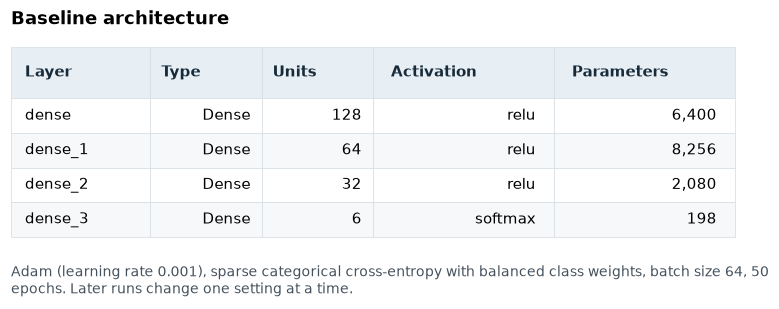

**Table 3.** Baseline network: 49 inputs, three ReLU hidden layers, six-class softmax output, 16,934 trainable parameters.

Saved assets/tables/table_03_baseline_architecture.png
Saved data/results/table_03_baseline_architecture.csv


In [9]:
keras.utils.set_random_seed(SEED)
baseline_config = RunConfig("Baseline")
n_inputs = X["train"].shape[1]
architecture = build_model(n_inputs, baseline_config, seed=SEED)
layer_table = pd.DataFrame(
    [
        {
            "Layer": layer.name,
            "Type": type(layer).__name__,
            "Units": layer.units,
            "Activation": layer.activation.__name__,
            "Parameters": layer.count_params(),
        }
        for layer in architecture.layers
    ]
)
save_table(
    layer_table,
    "table_03_baseline_architecture",
    "Baseline architecture",
    caption=f"**Table 3.** Baseline network: {n_inputs} inputs, three ReLU hidden layers, "
    f"six-class softmax output, {architecture.count_params():,} trainable parameters.",
    formats={"Units": "d", "Parameters": ",d"},
    note="Adam (learning rate 0.001), sparse categorical cross-entropy with balanced class "
    "weights, batch size 64, 50 epochs. Later runs change one setting at a time.",
    width=7,
)

Baseline: 50/50 epochs, validation accuracy 0.577, macro F1 0.445


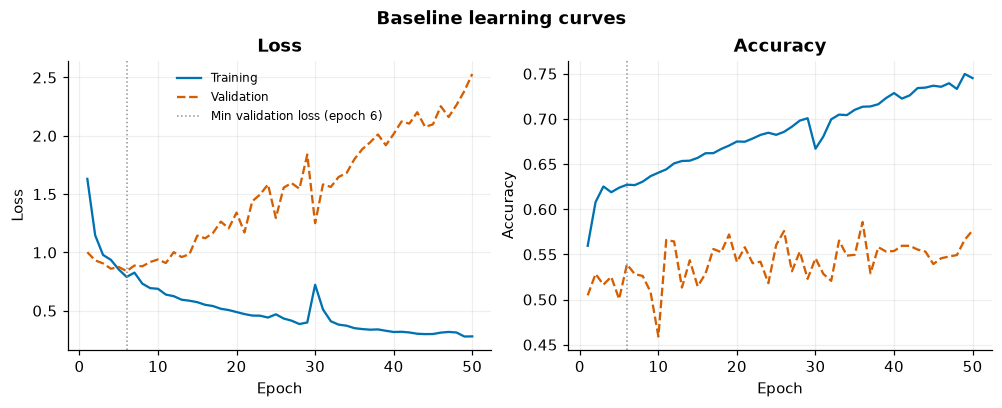

**Figure 3.** Baseline training and validation loss and accuracy by epoch. Both losses use the same class weights; the dotted line marks the epoch of minimum validation loss.

Saved assets/figures/fig_03_baseline_learning_curves.png


In [10]:
baseline = run(baseline_config)
fig = plot_baseline_curves("Baseline", title="Baseline learning curves")
show_figure(
    fig,
    "fig_03_baseline_learning_curves",
    "**Figure 3.** Baseline training and validation loss and accuracy by epoch. Both losses "
    "use the same class weights; the dotted line marks the epoch of minimum validation loss.",
)

**Readout:** Validation loss bottoms out at 0.84 in epoch 6, then rises to 2.53 while
training loss falls to 0.28: the baseline overfits. Final validation accuracy is 0.577,
macro F1 is 0.445, and the post-training accuracy gap is 19.6 percentage points.

### Gradient descent and learning rate

Keep the architecture fixed and train with SGD at 0.1, 0.01, and 0.001. SGD subtracts the
learning rate times the batch gradient from each weight; compare how step size affects
learning speed and stability.

In [11]:
for name, learning_rate in [("GD-1", 0.1), ("GD-2", 0.01), ("GD-3", 0.001)]:
    run(replace(baseline_config, name=name, optimizer="SGD", learning_rate=learning_rate))

GD-1: 50/50 epochs, validation accuracy 0.439, macro F1 0.324
GD-2: 50/50 epochs, validation accuracy 0.555, macro F1 0.448
GD-3: 50/50 epochs, validation accuracy 0.532, macro F1 0.375


### Regularization

Return to Adam at 0.001. Add L2 of 0.001 to discourage large hidden-layer weights, then test
dropout of 0.2 and 0.5 after the first two hidden layers, without L2. The baseline supplies
the dropout-0 comparison. Change one regularizer at a time to isolate its effect.

In [12]:
run(replace(baseline_config, name="L2", l2=0.001))
for name, rate in [("Dropout-1", 0.2), ("Dropout-2", 0.5)]:
    run(replace(baseline_config, name=name, dropout=rate))

L2: 50/50 epochs, validation accuracy 0.534, macro F1 0.428
Dropout-1: 50/50 epochs, validation accuracy 0.535, macro F1 0.436
Dropout-2: 50/50 epochs, validation accuracy 0.516, macro F1 0.430


### Results and final model

Select the highest final-epoch validation macro F1, using validation loss to break ties.
Keep the full 50-epoch budget to compare overfitting behavior. The final row repeats the
selected run; reuse its trained weights for test evaluation.

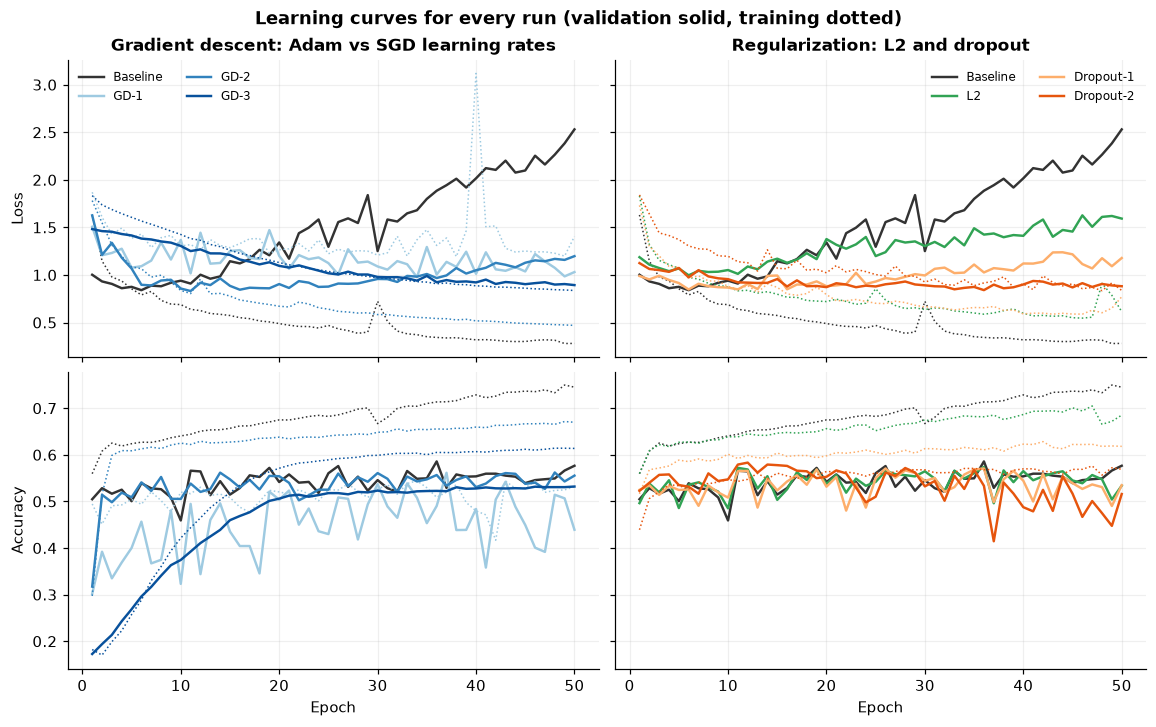

**Figure 4.** Validation (solid) and training (dotted) loss and accuracy by epoch for every run, with the baseline repeated in both groups as the reference. Both losses use the same class weights and include any L2 penalty on both splits; dropout is active only in training.

Saved assets/figures/fig_04_assignment_learning_curves.png


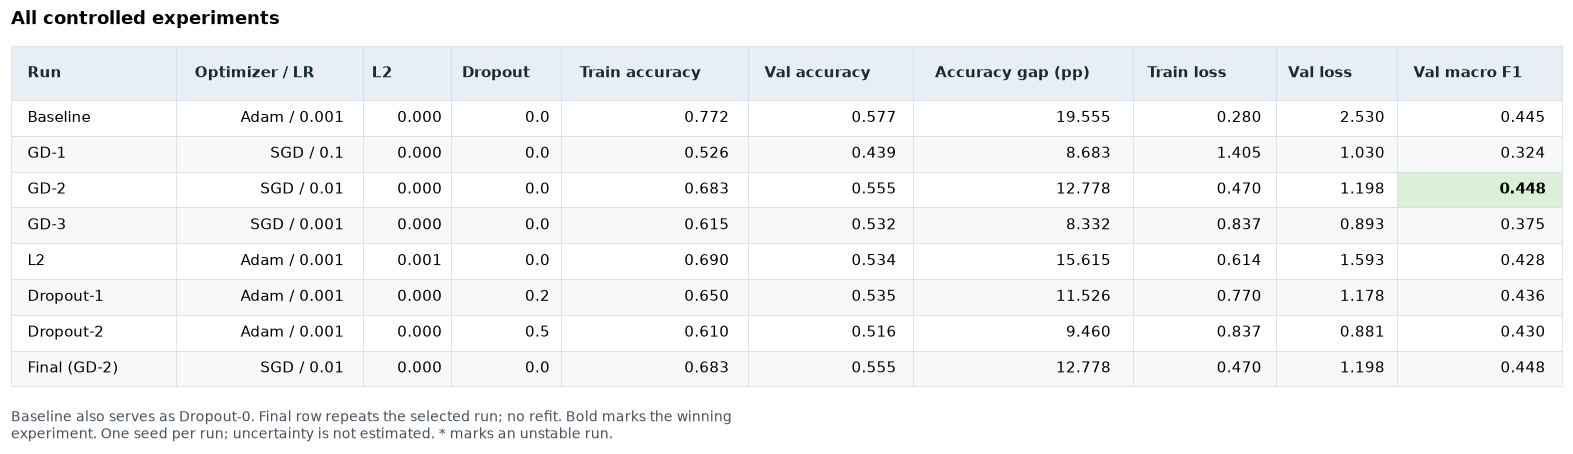

**Table 4.** Final-epoch results for every run. Losses are the class-weighted Keras losses on each split, including any L2 penalty on both sides. Accuracy is unweighted and evaluated after training with dropout disabled; gap is train minus validation in percentage points (pp).

Saved assets/tables/table_04_training_experiments.png
Saved data/results/table_04_training_experiments.csv


**Final assignment model: GD-2.**

In [13]:
fig = plot_run_groups(
    {
        "Gradient descent: Adam vs SGD learning rates": ["Baseline", "GD-1", "GD-2", "GD-3"],
        "Regularization: L2 and dropout": ["Baseline", "L2", "Dropout-1", "Dropout-2"],
    },
    title="Learning curves for every run",
)
show_figure(
    fig,
    "fig_04_assignment_learning_curves",
    "**Figure 4.** Validation (solid) and training (dotted) loss and accuracy by epoch for every "
    "run, with the baseline repeated in both groups as the reference. Both losses use the same "
    "class weights and include any L2 penalty on both splits; dropout is active only in training.",
)

candidates = {
    name: results[name]
    for name in ["Baseline", "GD-1", "GD-2", "GD-3", "L2", "Dropout-1", "Dropout-2"]
}
selected = select_best(candidates)
comparison = pd.DataFrame(
    [
        {
            "Run": name + ("" if result.completed else "*"),
            "Optimizer / LR": f"{result.config.optimizer} / {result.config.learning_rate:g}",
            "L2": result.config.l2,
            "Dropout": result.config.dropout,
            "Train accuracy": final_metric(result, "train_accuracy"),
            "Val accuracy": final_metric(result, "validation_accuracy"),
            "Accuracy gap (pp)": 100
            * (
                final_metric(result, "train_accuracy") - final_metric(result, "validation_accuracy")
            ),
            "Train loss": final_metric(result, "loss"),
            "Val loss": final_metric(result, "val_loss"),
            "Val macro F1": final_metric(result, "validation_macro_f1"),
        }
        for name, result in [*candidates.items(), (f"Final ({selected.config.name})", selected)]
    ]
)
save_table(
    comparison,
    "table_04_training_experiments",
    "All controlled experiments",
    caption="**Table 4.** Final-epoch results for every run. Losses are the class-weighted "
    "Keras losses on each split, including any L2 penalty on both sides. Accuracy is unweighted "
    "and evaluated after training with dropout disabled; gap is train minus validation in "
    "percentage points (pp).",
    formats={"L2": ".3f", "Dropout": ".1f", **{c: ".3f" for c in comparison.columns[4:]}},
    emphasize=("Val macro F1", "max"),
    width=15,
    note="Baseline also serves as Dropout-0. Final row repeats the selected run; no refit. "
    "Bold marks the winning experiment. One seed per run; uncertainty is not estimated. "
    "* marks an unstable run.",
)
display(Markdown(f"**Final assignment model: {selected.config.name}.**"))

**Readout**

- SGD 0.01 reaches 0.50 validation accuracy first among SGD runs (epoch 2) and gives the best
  macro F1, 0.448. SGD 0.1 is erratic; 0.001 is still improving at epoch 50.
- L2 lowers validation loss to 1.59 but also lowers macro F1 to 0.428. The accuracy gap
  narrows from 19.6 to 15.6 percentage points.
- Dropout 0.2 and 0.5 narrow the gap to 11.5 and 9.5 points. Masking makes fitting harder;
  validation uses all units. Table 4 measures both accuracies with masks off.
- Dropout 0.5 gives lower validation loss than 0.2, but lower macro F1 (0.430 versus 0.436)
  and accuracy (0.516 versus 0.535). Neither dropout run improves macro F1 over the
  baseline in this single-seed comparison.

### Test evaluation

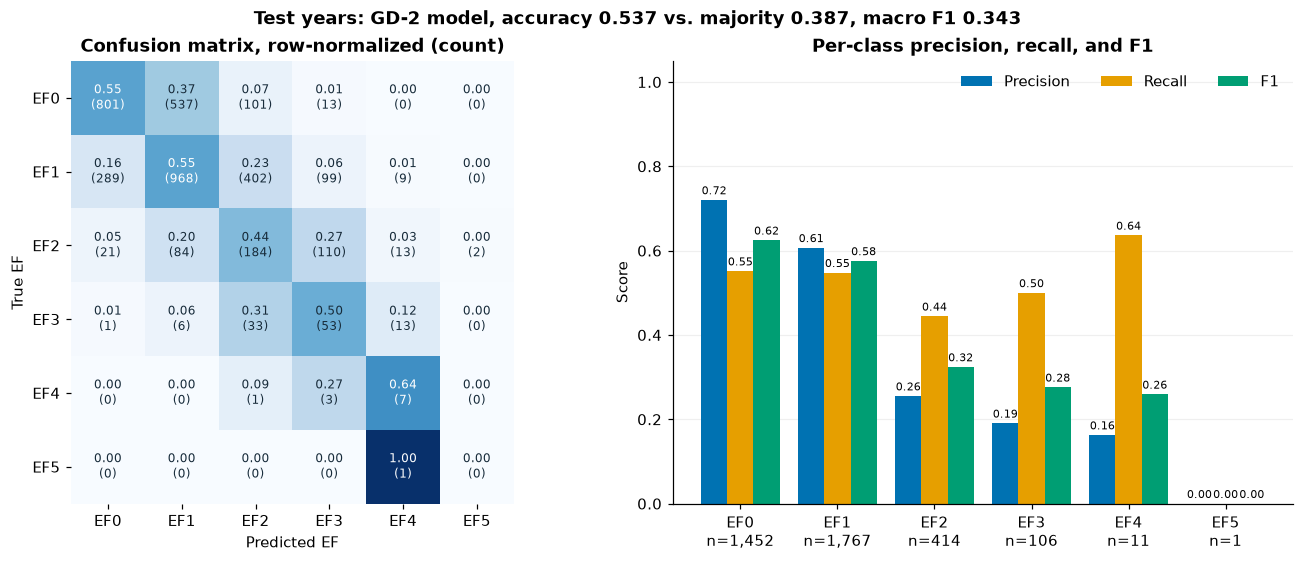

**Figure 5.** Test-year confusion matrix and per-class metrics for the GD-2 model. Cells show the share of each true class (row) with counts in parentheses.

Saved assets/figures/fig_05_test_assignment.png


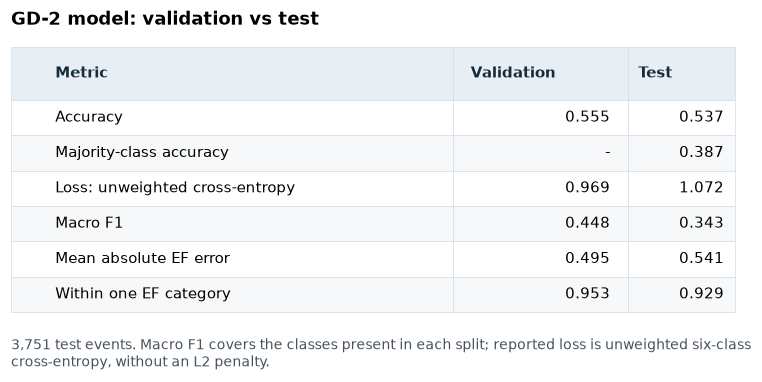

**Table 5.** The final assignment model on the validation years (2020-2022) used for selection and the test years (2023-2025), scored once in this workflow.

Saved assets/tables/table_05_assignment_test_summary.png
Saved data/results/table_05_assignment_test_summary.csv


In [14]:
assignment_test = evaluate_test(selected)
show_test_figure(selected, assignment_test, number=5, slug="assignment")
summary = pd.DataFrame(
    {
        "Metric": [label for label, _ in SUMMARY_ROWS],
        "Validation": [
            None if key == "majority" else final_metric(selected, f"validation_{key}")
            for _, key in SUMMARY_ROWS
        ],
        "Test": [assignment_test[key] for _, key in SUMMARY_ROWS],
    }
)
save_table(
    summary,
    "table_05_assignment_test_summary",
    f"{selected.config.name} model: validation vs test",
    caption="**Table 5.** The final assignment model on the validation years (2020-2022) used for "
    "selection and the test years (2023-2025), scored once in this workflow.",
    formats={"Validation": ".3f", "Test": ".3f"},
    width=7,
    note=f"{len(y['test']):,} test events. Macro F1 covers the classes present in each split; "
    "reported loss is unweighted six-class cross-entropy, without an L2 penalty.",
)

**Readout:** GD-2 reaches 0.537 test accuracy against 0.387 for always predicting EF0,
with loss 1.072 and six-class macro F1 0.343. Severe categories are often overpredicted:
EF3 recall is 0.50 at precision 0.19. EF5 has one test event, predicted as EF4.

Validation macro F1 covers five classes. Test macro F1 excluding EF5 is 0.412, so part of
the apparent drop comes from averaging over different class sets.

## 6. Feature Groups

Retrain the selected configuration without each feature group and its missingness indicators,
keeping the same events and training settings. Compare validation results to measure each
group's predictive contribution; these comparisons do not use test scores.

Without radar: 50/50 epochs, validation accuracy 0.554, macro F1 0.400
Without final track: 50/50 epochs, validation accuracy 0.448, macro F1 0.289
Without land cover: 50/50 epochs, validation accuracy 0.541, macro F1 0.413
Without track or land cover: 50/50 epochs, validation accuracy 0.427, macro F1 0.284


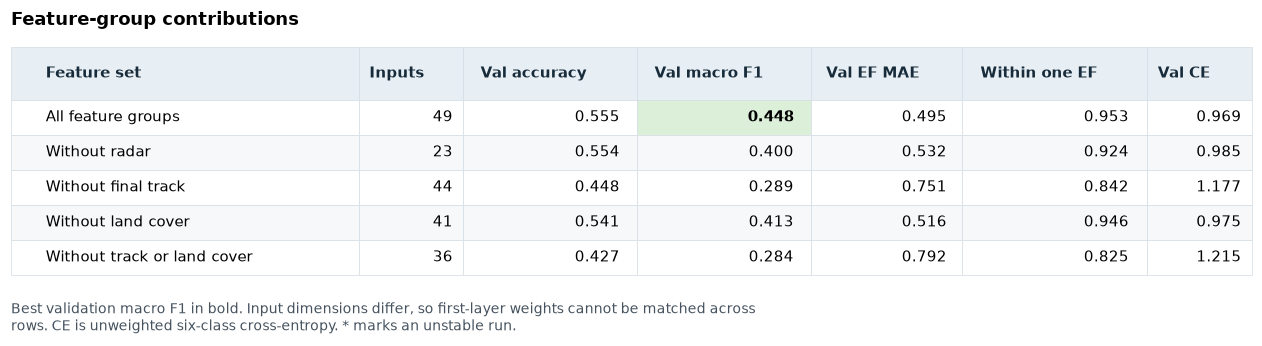

**Table 6.** Validation results for the GD-2 model retrained without each feature group, on the same events and training settings.

Saved assets/tables/table_06_feature_groups.png
Saved data/results/table_06_feature_groups.csv


In [15]:
removed_groups = {
    "Without radar": ["Onset radar", "Full-window radar"],
    "Without final track": ["Final track"],
    "Without land cover": ["Land cover"],
    "Without track or land cover": ["Final track", "Land cover"],
}
feature_runs = {"All feature groups": selected}
for name, groups in removed_groups.items():
    excluded = {column for group in groups for column in feature_groups[group]}
    columns = scope_columns([c for c in PREDICTORS if c not in excluded])
    feature_runs[name] = run(replace(selected.config, name=name), columns=columns)

feature_table = pd.DataFrame(
    [
        {
            "Feature set": name + ("" if result.completed else "*"),
            "Inputs": len(run_columns[result.config.name]),
            "Val accuracy": final_metric(result, "validation_accuracy"),
            "Val macro F1": final_metric(result, "validation_macro_f1"),
            "Val EF MAE": final_metric(result, "validation_ef_mae"),
            "Within one EF": final_metric(result, "validation_within_one"),
            "Val CE": final_metric(result, "validation_cross_entropy"),
        }
        for name, result in feature_runs.items()
    ]
)
save_table(
    feature_table,
    "table_06_feature_groups",
    "Feature-group contributions",
    caption=f"**Table 6.** Validation results for the {selected.config.name} model retrained "
    "without each feature group, on the same events and training settings.",
    formats={"Inputs": "d", **{c: ".3f" for c in feature_table.columns[2:]}},
    emphasize=("Val macro F1", "max"),
    width=12,
    note="Best validation macro F1 in bold. Input dimensions differ, so first-layer weights "
    "cannot be matched across rows. CE is unweighted six-class cross-entropy. * marks an "
    "unstable run.",
)

**Readout:** Removing final track causes the largest macro F1 drop, from 0.448 to 0.289.
Removing radar gives 0.400; removing land cover gives 0.413. Without both track and land cover,
the score is 0.284, so land cover adds little once track is absent in this run. That model
still includes full-window radar and is not an onset-only forecast.

In [16]:
history = pd.concat(
    [
        result.epochs.assign(
            run=name, **{k: v for k, v in vars(result.config).items() if k != "name"}
        )
        for name, result in results.items()
    ],
    ignore_index=True,
)
history.to_csv(RESULTS_DIR / "training_history.csv", index=False)
saved(RESULTS_DIR / "training_history.csv")

run_summary = {
    "runtime": runtime,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "cross_split_groups": cross_split_groups,
    "selected_run": selected.config.name,
    "runs": {
        name: {"config": vars(result.config), "completed": result.completed, **result.metrics}
        for name, result in results.items()
    },
    "test": {
        key: value.tolist() if isinstance(value, np.ndarray) else value
        for key, value in assignment_test.items()
    },
}
summary_path = RESULTS_DIR / "run_summary.json"
summary_path.write_text(json.dumps(run_summary, indent=2) + "\n")
saved(summary_path)

Saved data/results/training_history.csv
Saved data/results/run_summary.json


## 7. Findings and Limitations

SGD at 0.01 gives the best validation macro F1 among the tested settings. L2 and dropout
reduce the training-validation gap and validation loss, but all three lower
macro F1 relative to the baseline in this run. Final-track information contributes most to retrospective EF classification.

Interpret these results within one seed and temporal split. EF5 support is only 7/0/1 across
train/validation/test, and missing radar information limits coverage. Feature contributions
are predictive associations, not evidence of causation or physical wind intensity. Earlier
exploratory work also inspected these test years; this workflow evaluates its selected model
once, but the test period is not a fresh external holdout.